# Notebook 6 — ML Model Training & MLflow Tracking
**Project**: Real-Time Retail Analytics & Demand Prediction Platform  
**Author**: Vineet Joshi | ZDA25M007 | IIT Madras Zanzibar  
**Stack**: scikit-learn | MLflow (local tracking) | Delta Lake  

Trains Linear Regression (baseline), Random Forest, and Gradient Boosted Trees for demand prediction.  
All experiments tracked with MLflow.

---

## 6.1 Install & Config

In [1]:
import sys
!{sys.executable} -m pip install mlflow scikit-learn deltalake pyarrow boto3 matplotlib seaborn -q
print('Dependencies installed.')

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
googleapis-common-protos 1.62.0 requires protobuf!=3.20.0,!=3.20.1,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<5.0.0.dev0,>=3.19.5, but you have protobuf 6.33.6 which is incompatible.
pyopenssl 24.0.0 requires cryptography<43,>=41.0.5, but you have cryptography 46.0.7 which is incompatible.
Dependencies installed.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder

# MLflow — local file tracking (works without MLflow server)
os.environ['AWS_ACCESS_KEY_ID']     = 'admin'
os.environ['AWS_SECRET_ACCESS_KEY'] = 'bigdata123'

mlflow.set_tracking_uri('file:///home/jovyan/work/mlruns')
mlflow.set_experiment('retail-demand-prediction-v2')

print('✅ MLflow ready — local tracking at /home/jovyan/work/mlruns')

2026/04/25 11:40:24 INFO mlflow.tracking.fluent: Experiment with name 'retail-demand-prediction-v2' does not exist. Creating a new experiment.


✅ MLflow ready — local tracking at /home/jovyan/work/mlruns


## 6.2 Load Features from Delta Lake

In [3]:
from deltalake import DeltaTable

STORAGE = {
    'AWS_ENDPOINT_URL':           'http://minio:9000',
    'AWS_ACCESS_KEY_ID':          'admin',
    'AWS_SECRET_ACCESS_KEY':      'bigdata123',
    'AWS_ALLOW_HTTP':             'true',
    'AWS_S3_ALLOW_UNSAFE_RENAME': 'true',
    'AWS_REGION':                 'us-east-1'
}

dt = DeltaTable('s3://retail-v2/delta/features', storage_options=STORAGE)
df = dt.to_pandas()
print(f'Feature records loaded: {len(df):,}')
print(f'Columns: {df.columns.tolist()}')
df.head(3)

Feature records loaded: 272,535
Columns: ['StockCode', 'Country', 'Year', 'Month', 'WeekOfYear', 'DayOfWeek', 'TotalQuantity', 'TotalRevenue', 'AvgUnitPrice', 'NumInvoices', 'UniqueCustomers', 'Description']


,StockCode,Country,Year,Month,WeekOfYear,DayOfWeek,TotalQuantity,TotalRevenue,AvgUnitPrice,NumInvoices,UniqueCustomers,Description
0,10002,Australia,2010,3,9,3,24,20.021774,0.834241,1,1,INFLATABLE POLITICAL GLOBE
1,10002,Australia,2010,10,43,1,24,20.164432,0.840185,1,1,INFLATABLE POLITICAL GLOBE
2,10002,Denmark,2010,1,2,1,48,39.156549,0.815761,1,1,INFLATABLE POLITICAL GLOBE


## 6.3 Encode Categorical Features

In [4]:
le_stock   = LabelEncoder()
le_country = LabelEncoder()

df['StockCode_idx'] = le_stock.fit_transform(df['StockCode'].astype(str))
df['Country_idx']   = le_country.fit_transform(df['Country'].astype(str))

print(f'StockCode classes: {len(le_stock.classes_)}')
print(f'Country classes:   {len(le_country.classes_)}')

StockCode classes: 4045
Country classes:   40


## 6.4 Define Features & Target

In [5]:
FEATURES = [
    'Year', 'Month', 'WeekOfYear', 'DayOfWeek',
    'AvgUnitPrice', 'NumInvoices', 'UniqueCustomers',
    'TotalRevenue', 'StockCode_idx', 'Country_idx'
]
TARGET = 'TotalQuantity'

print(f'Features ({len(FEATURES)}): {FEATURES}')
print(f'Target: {TARGET}')
print(f'\nTarget stats:')
print(df[TARGET].describe())

Features (10): ['Year', 'Month', 'WeekOfYear', 'DayOfWeek', 'AvgUnitPrice', 'NumInvoices', 'UniqueCustomers', 'TotalRevenue', 'StockCode_idx', 'Country_idx']
Target: TotalQuantity

Target stats:
count    272535.000000
mean         25.460370
std         237.250064
min           1.000000
25%           3.000000
50%           8.000000
75%          24.000000
max       74215.000000
Name: TotalQuantity, dtype: float64


## 6.5 Time-Based Train/Test Split (80/20)

In [6]:
df = df.sort_values(['Year', 'WeekOfYear', 'DayOfWeek']).reset_index(drop=True)

split = int(len(df) * 0.8)
train = df.iloc[:split]
test  = df.iloc[split:]

X_train = train[FEATURES].fillna(0)
y_train = train[TARGET]
X_test  = test[FEATURES].fillna(0)
y_test  = test[TARGET]

print(f'Train: {len(X_train):,} rows ({len(X_train)/len(df)*100:.0f}%)')
print(f'Test:  {len(X_test):,} rows ({len(X_test)/len(df)*100:.0f}%)')

Train: 218,028 rows (80%)
Test:  54,507 rows (20%)


## 6.6 Evaluation Helper

In [7]:
def evaluate_model(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f'{name:25s} | RMSE: {rmse:>10.4f} | MAE: {mae:>10.4f} | R²: {r2:>8.4f}')
    return {'rmse': rmse, 'mae': mae, 'r2': r2}

## 6.7 Model 1 — Linear Regression (Baseline)

In [8]:
with mlflow.start_run(run_name='LR-Baseline'):
    mlflow.set_tag('model_type', 'LinearRegression')
    mlflow.log_param('model', 'LinearRegression')
    mlflow.log_param('n_features', len(FEATURES))
    mlflow.log_param('train_size', len(X_train))
    mlflow.log_param('test_size', len(X_test))
    
    lr = LinearRegression()
    lr.fit(X_train, y_train)
    lr_pred = lr.predict(X_test)
    
    lr_m = evaluate_model('Linear Regression', y_test, lr_pred)
    mlflow.log_metrics(lr_m)
    mlflow.sklearn.log_model(lr, 'model')

2026/04/25 11:42:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Linear Regression         | RMSE:    87.9722 | MAE:    19.2127 | R²:   0.9289


2026/04/25 11:42:13 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


## 6.8 Model 2 — Random Forest

In [9]:
with mlflow.start_run(run_name='RandomForest'):
    rf_params = {'n_estimators': 100, 'max_depth': 8, 'min_samples_split': 5, 'random_state': 42}
    mlflow.set_tag('model_type', 'RandomForest')
    mlflow.log_params(rf_params)
    
    rf = RandomForestRegressor(**rf_params, n_jobs=-1)
    rf.fit(X_train, y_train)
    rf_pred = rf.predict(X_test)
    
    rf_m = evaluate_model('Random Forest', y_test, rf_pred)
    mlflow.log_metrics(rf_m)
    mlflow.sklearn.log_model(rf, 'model')

2026/04/25 11:42:35 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Random Forest             | RMSE:   294.4546 | MAE:     4.4451 | R²:   0.2037


2026/04/25 11:42:35 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


## 6.9 Model 3 — Gradient Boosted Trees (Advanced)

In [10]:
with mlflow.start_run(run_name='GBT-Advanced'):
    gbt_params = {'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.1, 
                  'subsample': 0.8, 'random_state': 42}
    mlflow.set_tag('model_type', 'GradientBoosting')
    mlflow.log_params(gbt_params)
    
    gbt = GradientBoostingRegressor(**gbt_params)
    gbt.fit(X_train, y_train)
    gbt_pred = gbt.predict(X_test)
    
    gbt_m = evaluate_model('Gradient Boosting', y_test, gbt_pred)
    mlflow.log_metrics(gbt_m)
    mlflow.sklearn.log_model(gbt, 'model')

2026/04/25 11:44:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Gradient Boosting         | RMSE:   299.5488 | MAE:     2.4850 | R²:   0.1759


2026/04/25 11:44:28 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


## 6.10 Compare All Models

In [11]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'Gradient Boosting'],
    'RMSE':  [lr_m['rmse'], rf_m['rmse'], gbt_m['rmse']],
    'MAE':   [lr_m['mae'],  rf_m['mae'],  gbt_m['mae']],
    'R²':    [lr_m['r2'],   rf_m['r2'],   gbt_m['r2']],
})

print('='*65)
print('MODEL COMPARISON')
print('='*65)
print(results.to_string(index=False))

best = results.loc[results['R²'].idxmax()]
print(f'\n🏆 Best model: {best["Model"]} (R² = {best["R²"]:.4f})')

MODEL COMPARISON
            Model       RMSE       MAE       R²
Linear Regression  87.972208 19.212693 0.928924
    Random Forest 294.454616  4.445121 0.203718
Gradient Boosting 299.548814  2.484958 0.175927

🏆 Best model: Linear Regression (R² = 0.9289)


## 6.11 Feature Importance (GBT)

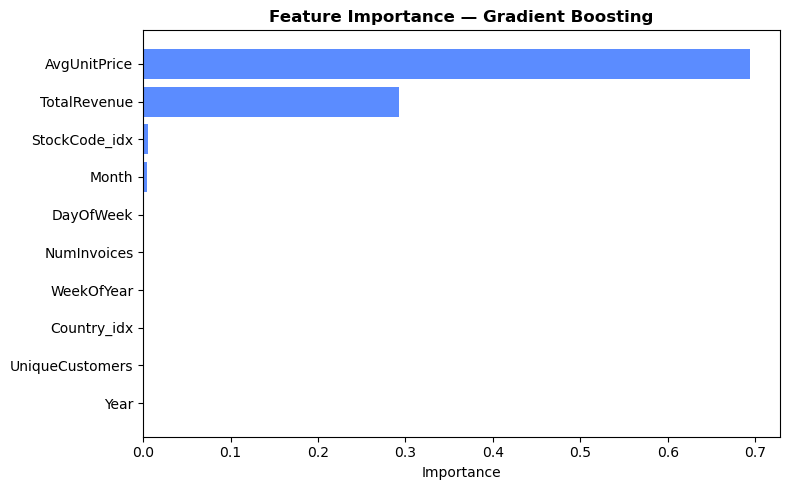

Feature importance saved.


In [12]:
fi = pd.DataFrame({
    'Feature': FEATURES,
    'Importance': gbt.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(fi['Feature'], fi['Importance'], color='#5b8cff')
ax.set_title('Feature Importance — Gradient Boosting', fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('/home/jovyan/work/feature_importance.png', dpi=150)
plt.show()

# Log to MLflow
fi.to_csv('/home/jovyan/work/feature_importance.csv', index=False)
print('Feature importance saved.')

## 6.12 Actual vs Predicted Plot

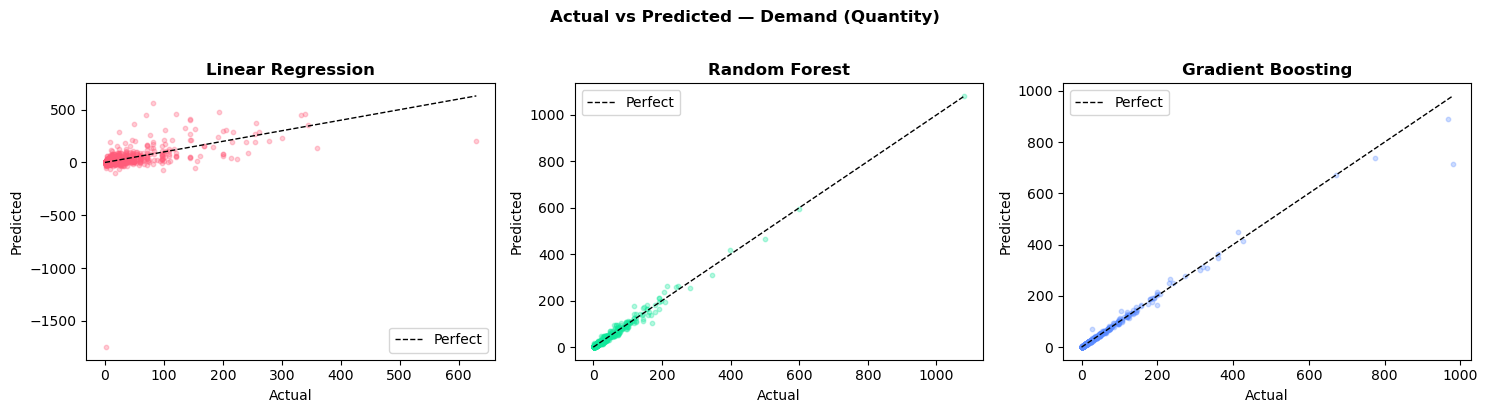

Plots saved.


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models = [('Linear Regression', lr_pred), ('Random Forest', rf_pred), ('Gradient Boosting', gbt_pred)]
colors = ['#ff5c7a', '#10e89b', '#5b8cff']

for ax, (name, pred), color in zip(axes, models, colors):
    # Sample 2000 points for clarity
    idx = np.random.choice(len(y_test), min(2000, len(y_test)), replace=False)
    ax.scatter(y_test.values[idx], pred[idx], alpha=0.3, s=10, color=color)
    max_val = max(y_test.values[idx].max(), pred[idx].max())
    ax.plot([0, max_val], [0, max_val], 'k--', linewidth=1, label='Perfect')
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.legend()

plt.suptitle('Actual vs Predicted — Demand (Quantity)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/home/jovyan/work/actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plots saved.')

## 6.13 Summary

In [14]:
print('='*55)
print('NOTEBOOK 6 COMPLETE')
print('='*55)
print(f'  Features used    : {len(FEATURES)}')
print(f'  Train size       : {len(X_train):,}')
print(f'  Test size        : {len(X_test):,}')
print(f'  Models trained   : 3 (LR, RF, GBT)')
print(f'  Best model       : {best["Model"]} (R² = {best["R²"]:.4f})')
print(f'  MLflow runs      : /home/jovyan/work/mlruns')
print(f'  Split strategy   : Time-based 80/20')
print()
print('Artifacts saved:')
print('  feature_importance.png')
print('  feature_importance.csv')
print('  actual_vs_predicted.png')
print()
print('Next: Notebook 7 — Model Evaluation & Predictions')

NOTEBOOK 6 COMPLETE
  Features used    : 10
  Train size       : 218,028
  Test size        : 54,507
  Models trained   : 3 (LR, RF, GBT)
  Best model       : Linear Regression (R² = 0.9289)
  MLflow runs      : /home/jovyan/work/mlruns
  Split strategy   : Time-based 80/20

Artifacts saved:
  feature_importance.png
  feature_importance.csv
  actual_vs_predicted.png

Next: Notebook 7 — Model Evaluation & Predictions
